<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

In [12]:
# Ваш код
!pip install datasets nltk -q
import io
import gzip
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from datasets import load_dataset
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_ru = stopwords.words('russian')

url = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz"
df = pd.read_csv(url, compression='gzip', usecols=['text', 'topic'], nrows=10000)

df = df.dropna(subset=['text', 'topic'])
df = df[df['text'].str.strip() != '']
df['topic'] = df['topic'].astype(str)

X = df['text'].values
y = df['topic'].values


print("Classes:", len(set(y)))
print("Prim text:", X[0][:200])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Classes: 15
Prim text: Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онколо


### Разделите данные на обучающую и валидационную выборки

In [13]:
# Ваш код
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_tr)}, Val: {len(X_val)}")

Train: 7997, Val: 2000


### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [15]:
# Ваш код
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([('vec', TfidfVectorizer(stop_words=stop_ru)),('nb', MultinomialNB())])
params = {'vec__max_df': [0.5, 0.8, 1.0], 'vec__min_df': [2, 5], 'vec__ngram_range': [(1,1), (1,2)], 'nb__alpha': [0.1, 0.5, 1.0]}

grid = GridSearchCV(pipe, params, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_tr, y_tr)

print("Best params:", grid.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best params: {'nb__alpha': 0.1, 'vec__max_df': 0.5, 'vec__min_df': 5, 'vec__ngram_range': (1, 2)}


### Вывод матрицы ошибок:

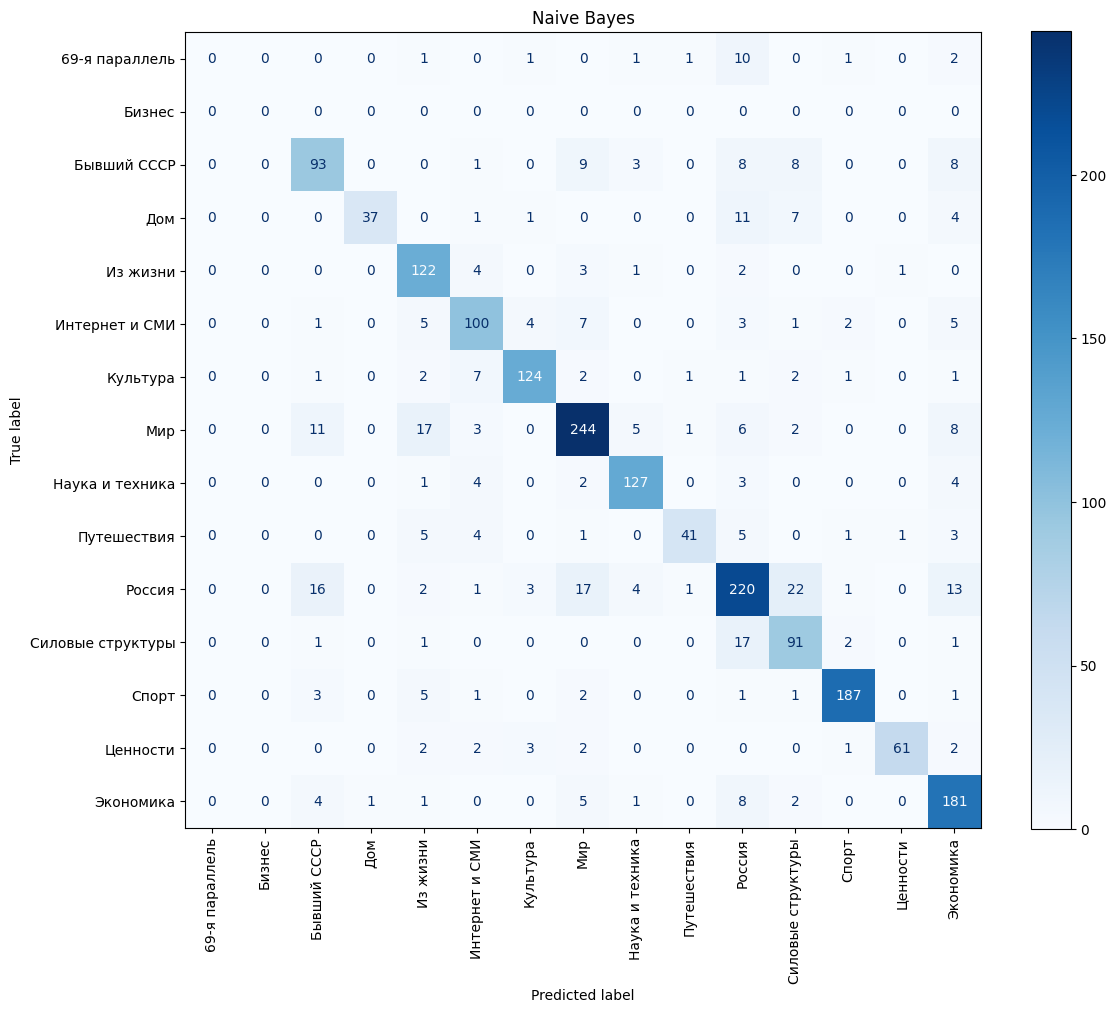

In [17]:
# Ваш код
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = grid.predict(X_val)
cm = confusion_matrix(y_val, y_pred, labels=grid.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid.classes_)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues', values_format='d')
plt.title('Naive Bayes')
plt.tight_layout()
plt.show()

### Оценка точности:

In [18]:
# Ваш код
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_val, y_pred)
print(f"Acc: {acc:.4f}")

Acc: 0.8140


## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [19]:
# Ваш код
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe_svm = Pipeline([('vec', TfidfVectorizer(stop_words=stop_ru)),('svm', LinearSVC(random_state=42, max_iter=5000))])
params_svm = {'vec__max_df': [0.5, 0.8, 1.0], 'vec__min_df': [2, 5], 'vec__ngram_range': [(1,1), (1,2)], 'svm__C': [0.1, 1.0, 10.0]}
grid_svm = GridSearchCV(pipe_svm, params_svm, cv=3, n_jobs=-1, verbose=1)
grid_svm.fit(X_tr, y_tr)

print("Best params SVM:", grid_svm.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best params SVM: {'svm__C': 10.0, 'vec__max_df': 0.5, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}


### Вывод матрицы ошибок:

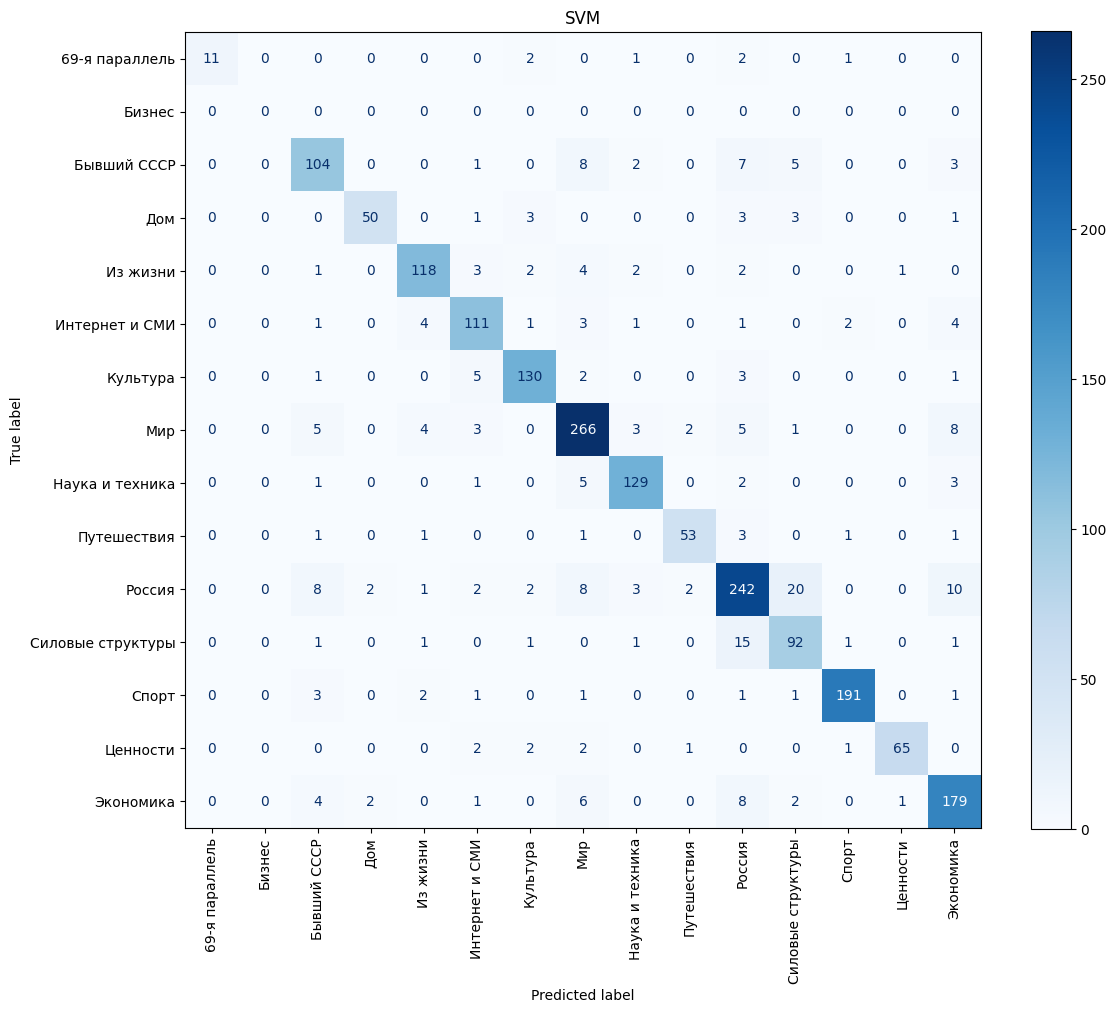

In [20]:
# Ваш код
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_svm = grid_svm.predict(X_val)
cm_svm = confusion_matrix(y_val, y_pred_svm, labels=grid_svm.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=grid_svm.classes_)
fig, ax = plt.subplots(figsize=(12, 10))
disp_svm.plot(ax=ax, xticks_rotation=90, cmap='Blues', values_format='d')
plt.title('SVM')
plt.tight_layout()
plt.show()

### Оценка точности:

In [21]:
# Ваш код
from sklearn.metrics import accuracy_score

acc_svm = accuracy_score(y_val, y_pred_svm)
print(f"SVM acc: {acc_svm:.4f}")

SVM acc: 0.8705


## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [ ]:
# Ваш код
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([('vec', TfidfVectorizer(stop_words=stop_ru)), ('dt', DecisionTreeClassifier(random_state=42))])
params_dt = {'vec__max_df': [0.5, 0.8], 'vec__min_df': [2, 5], 'vec__ngram_range': [(1,1), (1,2)], 'dt__max_depth': [10, 20, None], 'dt__min_samples_split': [2, 5], 'dt__min_samples_leaf': [1, 2]}
grid_dt = GridSearchCV(pipe_dt, params_dt, cv=3, n_jobs=-1, verbose=1)
grid_dt.fit(X_tr, y_tr)

print("Best params Decision Tree:", grid_dt.best_params_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


### Вывод матрицы ошибок:

In [ ]:
# Ваш код

### Оценка точности:

In [ ]:
# Ваш код

## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [ ]:
# Ваш код

### Вывод матрицы ошибок:

In [ ]:
# Ваш код

### Оценка точности:

In [ ]:
# Ваш код

## Подведите общие итоги и сделайте выводы

In [ ]:
# Ваш код

      Ваши выводы